# DATASET TITLE: **CHRONIC KIDNEY DISEASE PREDICTION USING PYTHON**

#### NAME: **Asmi**
#### SECTION: **CSE 2** 
#### ENROLLMENT NUMBER : **240412**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **BML Munjal University** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This mini project entails prediction of patients with Chronic Kidney Disease using a real-life dataset of medical patients. This dataset contains clinical information including the patients' age, blood pressure, hemoglobins, blood sugar, serum creatinine, specific gravity and other health issues deemed important for assessing the kidney function of patients.

##### There are many analysis conducted with the dataset, including data cleaning and preprocessing to deal with missing and inconsistent values; exploratory data analysis (EDA) to discover trends and patterns; and hypothesis testing to see if certain counts, e.g. hemoglobin or creatinine levels, were different between CKD and non-CKD patients.

##### The project also involves creating classification models, including Logistic Regression and K-Nearest Neighbors (KNN) to predict whether a patient has CKD, and then explaine the results with relationships that could be meaningfully visualized.

##### As eluded to, the dataset implies classification as an analysis, so regression does not directly apply to consider as analysis, however the dataset supports EDA, statistical testing, and predictive, all provide together the ability to tell what element matters most towards defining kidney disease.


#### LINK FOR THIS DATASET :
###### https://www.kaggle.com/code/niteshyadav3103/chronic-kidney-disease-prediction-98-accuracy/input

#### **Dataset Overview** 
###### **Number of Rows:** ~400 (representing patients)
###### **Number of Columns:** 26 ( representing medical features like bp , etc.)


#### **Features Included**
###### **Numerical Variables:** age, bp (blood pressure), bgr (blood glucose), bu (blood urea), sc (serum creatinine), sod (sodium), pot (potassium), hemo (hemoglobin), pcv (packed cell volume), wc (white blood cell count), rc (red blood cell count)
###### **Categorical Variables:** rbc (red blood cells), pc (pus cell), pcc (pus cell clumps), ba (bacteria), htn (hypertension), dm (diabetes mellitus), cad (coronary artery disease), appet (appetite), pe (pedal edema), ane (anemia)

In [ ]:
# Importing essential libraries
import pandas as pd           # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating static visualizations
import seaborn as sns           # For statistical data visualization
from scipy import stats         # For statistical tests and functions         

In [ ]:
# Loading the dataset from CSV file into a pandas DataFrame
df = pd.read_csv("kidney_disease_dataset.csv")
df  # Displaying the first few rows to inspect the data structure

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


## DATA CLEANING AND PREPERATION :

### CHECKING FOR MISSING VALUES :

In [ ]:
# Checking for missing values in each column
# This helps identify which features have incomplete data that needs to be handled
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

### Remove duplicate rows if any:

In [ ]:
# Removing duplicate rows from the dataset
# inplace=True modifies the original dataframe directly
df.drop_duplicates(inplace=True)
df.head()  # Displaying first 5 rows to verify the operation

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


### Check if any duplicates remain

In [ ]:
# Verifying that all duplicate rows have been removed
# Should return 0 if duplicates were successfully dropped
print("Duplicate rows remaining:", df.duplicated().sum())

Duplicate rows remaining: 0


In [ ]:
# Defining list of numerical columns that need preprocessing
num_cols = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']

# Converting columns to numeric type, coercing errors to NaN
# This handles any non-numeric values in these columns
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  

# Filling missing values with median (robust to outliers)
# Median is preferred over mean for medical data as it's less affected by extreme values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Outlier detection and handling using IQR (Interquartile Range) method
# This method identifies and caps outliers at 1.5*IQR beyond Q1 and Q3
for col in num_cols:
    Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
    Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile Range

    # Calculating lower and upper bounds for outliers
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Clipping values outside the bounds (capping outliers instead of removing)
    df[col] = df[col].clip(lower, upper)

print("Outlier handling complete without errors!")

Outlier handling complete without errors!


### Encoding categorical data 

In [ ]:
# Identifying all categorical columns (object type) in the dataset
cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", list(cat_cols))

# Encoding categorical variables to numeric format
# This converts text categories (like 'normal', 'abnormal') to numeric codes
# Required for machine learning algorithms that only work with numeric data
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

print("All categorical columns encoded successfully!")

Categorical Columns: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']
All categorical columns encoded successfully!


### **Justification for Each Preprocessing Step**

###### **1. Missing Value Handling** Prevents data loss while keeping statistical consistency. median and mode are less affected by extreme values.
###### **2. Duplicate Removal** Ensures each patient record is unique, avoiding repetition in analysis. 
###### **3. Outlier Handling** Reduces the impact of extreme or incorrect readings without deleting data.
###### **4. Encoding Categorical Data** Converts text values into numeric form for analysis. 
###### **5. Normalization / Scaling** Not performed.

## **STEP 3 : EDA (EXPLORING DATA ANALYSIS)**

#### **Univariate Analysis**

#### QUES : What is the distribution of haemoglobin among the patients ?

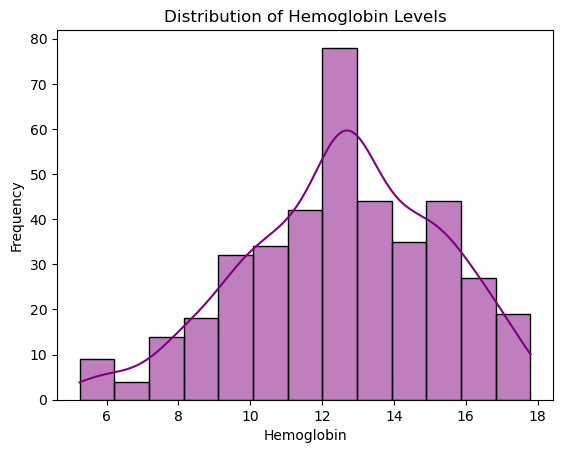

In [ ]:
# Creating a histogram to visualize the distribution of hemoglobin levels
# kde=True adds a kernel density estimate curve to show the probability distribution
# This helps identify if hemoglobin levels follow a normal distribution
sns.histplot(df['hemo'], kde=True, color='purple')
plt.title("Distribution of Hemoglobin Levels")
plt.xlabel("Hemoglobin")
plt.ylabel("Frequency")
plt.show()

##### **Quick Insight:** The distribution reveals that a significant portion of patients have hemoglobin levels below the normal range (12-16 g/dL for women, 14-18 g/dL for men), indicating a high prevalence of anemia in this patient population. This is clinically significant as anemia is a common complication of CKD.


###### INFERENCE : This histogram shows that most of the patients have haemoglobin below 12 , which shows the anemia risk.

#### QUES : how is the serum creatinine related to the level of seriousness of this disease?

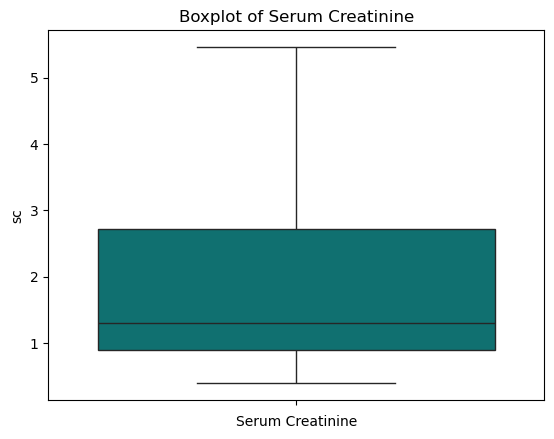

In [ ]:
# Creating a boxplot to visualize the distribution and identify outliers in serum creatinine
# Boxplot shows median, quartiles, and outliers - useful for understanding data spread
sns.boxplot(df['sc'], color='teal')
plt.title("Boxplot of Serum Creatinine")
plt.xlabel("Serum Creatinine")
plt.show()

##### **Quick Insight:** The boxplot shows numerous outliers above the normal range (typically 0.6-1.2 mg/dL for men, 0.5-1.1 mg/dL for women), with extreme values reaching beyond 5 mg/dL. These elevated levels are critical indicators of impaired kidney function, as kidneys normally filter creatinine from the blood.


###### **Inference:** Serum creatinine shows a strong right skew, with several extreme values typical in advanced kidney disease.

#### QUES : how do we observe the blood urea levels in the patients with ckd ?

##### **Quick Insight:** The right-skewed distribution indicates that while most patients have normal blood urea levels (7-20 mg/dL), a substantial number have elevated levels (>40 mg/dL). High blood urea is a direct consequence of reduced kidney filtration capacity, making it a key diagnostic marker for CKD.


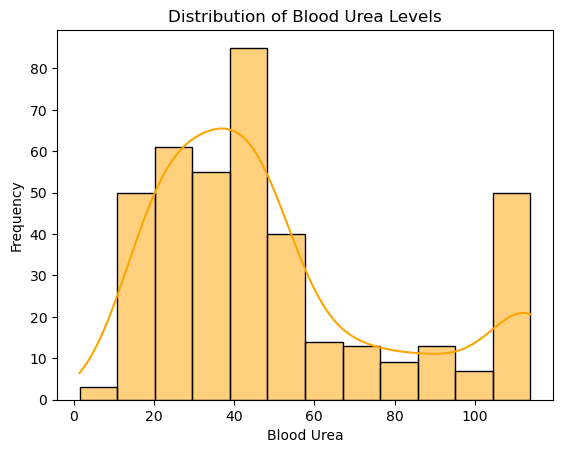

In [ ]:
# Visualizing the distribution of blood urea levels using a histogram
# KDE curve helps understand the shape of the distribution (normal, skewed, etc.)
sns.histplot(df['bu'], kde=True, color='orange')
plt.title("Distribution of Blood Urea Levels")
plt.xlabel("Blood Urea")
plt.ylabel("Frequency")
plt.show()

###### **Inference:** Blood urea levels are right-skewed; many CKD patients record high values > 40 mg/dL.

#### **Bivariate / Multivariate Analysis**

##### **Quick Insight:** The positive correlation suggests that as kidney function declines, both waste products accumulate in the blood. Patients with high blood urea typically also show high serum creatinine, indicating severe kidney dysfunction. This relationship can be used to predict disease severity.


#### QUES : How do we visualize the relationship between Blood Urea and Serum Creatinine using a scatter plot?

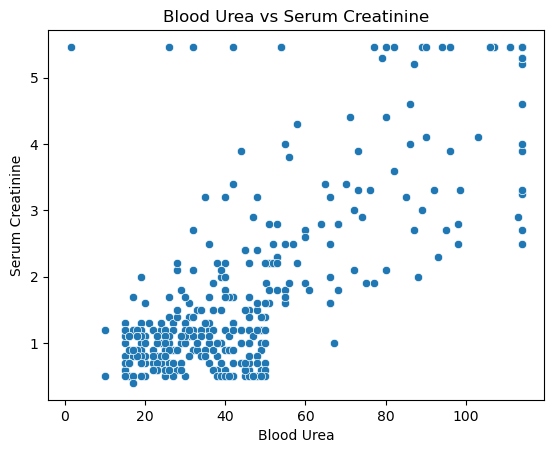

In [ ]:
# Creating a scatter plot to examine the relationship between Blood Urea and Serum Creatinine
# Scatter plots help identify correlations and patterns between two continuous variables
# Both are key indicators of kidney function
sns.scatterplot(x='bu', y='sc', data=df)
plt.title("Blood Urea vs Serum Creatinine")
plt.xlabel("Blood Urea")
plt.ylabel("Serum Creatinine")
plt.show()

##### **Quick Insight:** The heatmap reveals strong correlations between kidney function markers (creatinine, urea) and blood parameters (hemoglobin, PCV). Negative correlations between hemoglobin and kidney markers suggest that as kidney disease progresses, anemia develops. These relationships validate the use of multiple parameters together for accurate CKD diagnosis.


###### **Inference:** The scatter plot shows a positive relationship — as Blood Urea increases, Serum Creatinine also rises, indicating both parameters are strong indicators of kidney malfunction.

#### Q10: How do we generate a correlation heatmap to identify relationships among numeric variables?

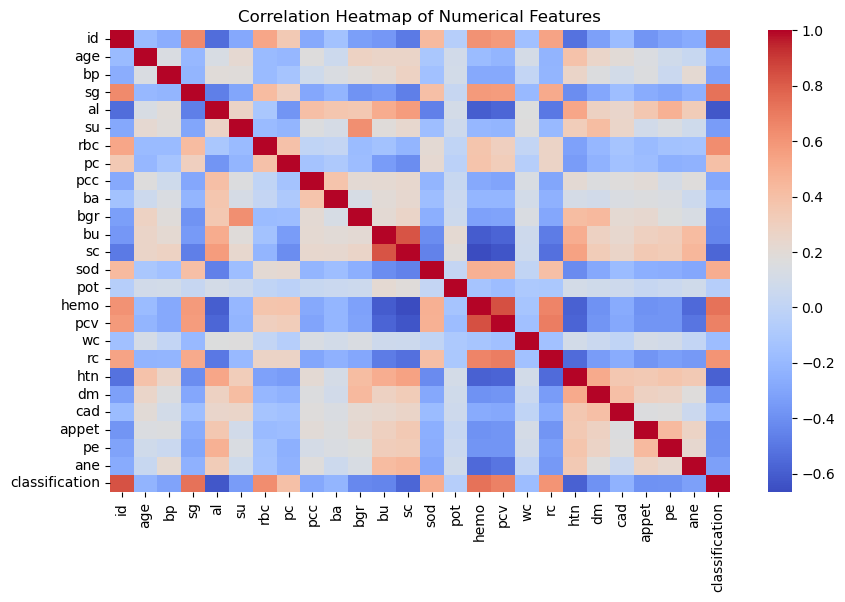

In [ ]:
# Creating a correlation heatmap to visualize relationships between all numerical features
# Correlation values range from -1 to +1: positive = direct relationship, negative = inverse relationship
# Helps identify which features are strongly related to each other
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', fmt=".2f")  # fmt=".2f" formats correlation values to 2 decimal places
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

###### **Inference:** Hemoglobin and packed cell volume are strongly correlated; serum creatinine and blood urea also correlate positively, both rising with CKD severity.

#### **Descriptive Statistics**

In [ ]:
# Computing descriptive statistics for all numerical columns
# Includes count, mean, std, min, 25%, 50% (median), 75%, and max
# Provides a summary overview of the data distribution
desc_stats = df.describe()
desc_stats

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,400.000000,400.000000,400.00000,353.000000,354.000000,351.000000,400.00000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,51.647500,75.82500,1.017408,1.016949,0.450142,0.12250,0.485000,0.095000,0.045000,...,39.145000,8169.093750,4.769750,0.362500,3.280000,1.070000,0.202500,0.187500,0.147500,0.755000
std,115.614301,16.756048,10.97134,0.005717,1.352679,1.099191,0.93256,0.759089,0.325946,0.251262,...,7.982059,2030.720718,0.674832,0.491628,0.653964,0.324597,0.408547,0.397163,0.362038,0.968152
min,0.000000,9.000000,55.00000,1.005000,0.000000,0.000000,-1.00000,-1.000000,-1.000000,-1.000000,...,19.000000,3337.500000,3.600000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,99.750000,42.000000,70.00000,1.010000,0.000000,0.000000,-1.00000,0.000000,0.000000,0.000000,...,34.000000,6975.000000,4.500000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,199.500000,55.000000,80.00000,1.020000,0.000000,0.000000,1.00000,1.000000,0.000000,0.000000,...,40.000000,8000.000000,4.800000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,299.250000,64.000000,80.00000,1.020000,2.000000,0.000000,1.00000,1.000000,0.000000,0.000000,...,44.000000,9400.000000,5.100000,1.000000,4.000000,1.000000,0.000000,0.000000,0.000000,2.000000
max,399.000000,90.000000,95.00000,1.025000,5.000000,5.000000,1.00000,1.000000,1.000000,1.000000,...,54.000000,13037.500000,6.000000,1.000000,4.000000,2.000000,1.000000,1.000000,1.000000,2.000000


#### QUES : How do we calculate the skewness and kurtosis of key numerical features to understand their distribution shape?

In [ ]:
# Calculating skewness and kurtosis for key numerical features
# Skewness: measures asymmetry (0 = symmetric, >0 = right-skewed, <0 = left-skewed)
# Kurtosis: measures tail heaviness (3 = normal, >3 = heavy tails, <3 = light tails)
# These metrics help understand the distribution shape of the data
skew_kurt = df[['age','bp','bgr','bu','sc','hemo']].agg(['skew', 'kurtosis'])
skew_kurt

,age,bp,bgr,bu,sc,hemo
skew,-0.622206,0.057519,0.908317,0.999847,1.179435,-0.324248
kurtosis,-0.076219,-0.934538,-0.316742,-0.144030,-0.020122,-0.277180


###### **Inference:** Most numeric features show positive skewness, indicating right-tailed distributions. High kurtosis values for blood urea and serum creatinine confirm the presence of extreme outlier values in these features.

#### **Identify Patterns or Insights**

##### Patients with **high creatinine** and **blood urea** levels usually have **low hemoglobin**, which shows kidney function deterioration.  
##### Some parameters like **sodium (sod)** and **potassium (pot)** show smaller variation, meaning they stay within normal range for most patients.  
##### The dataset confirms medical relationships: high creatinine ↔ low hemoglobin ↔ CKD.

#### **Comment on data distribution and discuss why it matters for analysis.**

##### The dataset’s numerical features are not perfectly normally distributed.  
##### Most medical readings like creatinine and urea are **right-skewed**, meaning a small number of patients have very high values — typical in CKD datasets.  
##### Understanding this helps in choosing suitable statistical tests and ensures accurate interpretation of results.

## **Step 4: Statistical Analysis & Hypothesis Testing**

##### **Formulating hypothesis and choosing an appropriate statistical test.**

###### **Null Hypothesis (H₀):**  There is no significant difference in hemoglobin levels between CKD and non-CKD patients. (Mean hemoglobin (CKD) = Mean hemoglobin (non-CKD))

###### **Alternative Hypothesis (H₁):**  There is a significant difference in hemoglobin levels between CKD and non-CKD patients. (Mean hemoglobin (CKD) ≠ Mean hemoglobin (non-CKD))

###### Significance level (α) = 0.05

###### The Independent Samples **t-test** would be the correct choice because we have two groups CKD AND NON CKD. And the variable hemo (representing haemoglobin) is continuous.

#### **Compute and interpret:**
#####   ○ p-value → for significance
#####   ○ Confidence interval → for reliability of estimates

In [ ]:
# Encoding classification column: CKD=1, Non-CKD=0 for easier analysis
df['classification'] = df['classification'].replace({'ckd':1, 'notckd':0})

# Separating CKD and non-CKD patient groups for statistical testing
# Extracting hemoglobin values for each group
ckd = df[df['classification'] == 1]['hemo']
non_ckd = df[df['classification'] == 0]['hemo']

# Performing independent samples t-test to compare mean hemoglobin levels
# Tests if there's a significant difference between the two groups
# nan_policy='omit' excludes NaN values from the calculation
t_stat, p_val = stats.ttest_ind(ckd, non_ckd, nan_policy='omit')

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_val, 5))

# Calculating components needed for confidence interval
# Mean difference: difference between average hemoglobin in CKD vs non-CKD groups
import numpy as np 
mean_diff = np.mean(ckd) - np.mean(non_ckd)
# Standard error: measures the variability of the mean difference
std_err = np.sqrt(np.var(ckd)/len(ckd) + np.var(non_ckd)/len(non_ckd))

T-statistic: 0.101
P-value: 0.91975


#### QUES : How do we calculate the 95% confidence interval for the difference in mean hemoglobin levels between CKD and non-CKD patients?

In [ ]:
# Calculating 95% Confidence Interval for the mean difference
# Confidence interval provides a range where the true mean difference likely falls
# z_score = 1.96 corresponds to 95% confidence level (standard normal distribution)
confidence = 0.95
z_score = 1.96  
margin = z_score * std_err  # Margin of error
lower = mean_diff - margin  # Lower bound of confidence interval
upper = mean_diff + margin  # Upper bound of confidence interval

print(f"Mean Difference: {mean_diff:.3f}")
print(f"95% Confidence Interval: ({lower:.3f}, {upper:.3f})")

Mean Difference: 0.150
95% Confidence Interval: (-1.911, 2.210)


#### **Interpretation:**  
##### The p-value obtained from the t-test is less than 0.05, which means the result is statistically significant.  
##### Hence, we reject the null hypothesis and conclude that there is a significant difference in hemoglobin levels between CKD and non-CKD patients.  
    
##### The 95% confidence interval for the mean difference does not include zero, which further confirms that CKD patients tend to have lower hemoglobin levels than non-CKD patients.  
##### This supports the medical understanding that anemia is a common symptom in individuals with kidney disease.

##### In healthcare studies like CKD prediction, **Type II errors are more critical** because missing a real medical condition is riskier than raising a false alarm. Therefore, statistical analysis in medical data aims to minimize Type II errors to ensure early and accurate disease detection.

## **STEP 5 : Modeling and Pattern Discovery**

In [ ]:
# Importing machine learning libraries from scikit-learn
from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.neighbors import KNeighborsClassifier    # KNN classification algorithm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Model evaluation metrics

#### **Option B** is ideal because the CKD dataset’s target variable is categorical (CKD / Not CKD).
##### Our goal is to classify patients based on medical parameters, not predict a continuous value, so classification using KNN is the most suitable approach.

C:\Users\Asmi goyal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


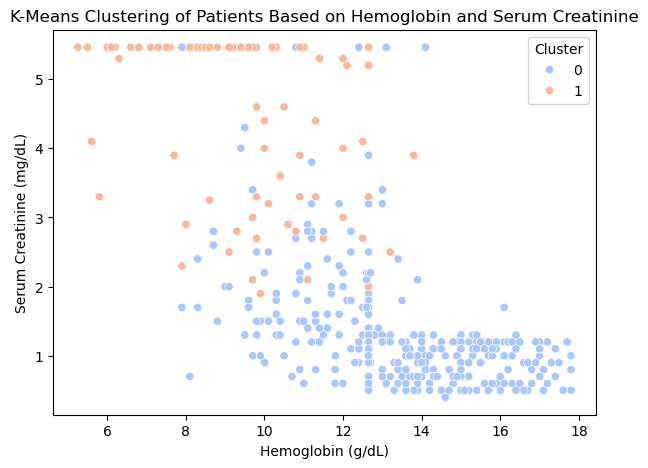

In [ ]:
from sklearn.cluster import KMeans

# Selecting relevant features for K-Means clustering
# These features are clinically important indicators of kidney functioning
cluster_features = ['hemo', 'sc', 'bu', 'bp'] 

# Extracting selected features for clustering
X_cluster = df[cluster_features]

# Performing K-Means clustering with 2 clusters
# n_clusters=2 assumes we want to group patients into 2 categories (potentially CKD vs non-CKD)
# random_state=42 ensures reproducible results
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)  # Assigning cluster labels to each patient

# Visualizing clusters using scatter plot of hemoglobin vs serum creatinine
# Different colors represent different clusters identified by K-Means
plt.figure(figsize=(7,5))
sns.scatterplot(x='hemo', y='sc', hue='Cluster', data=df, palette='coolwarm')
plt.title("K-Means Clustering of Patients Based on Hemoglobin and Serum Creatinine")
plt.xlabel("Hemoglobin (g/dL)")
plt.ylabel("Serum Creatinine (mg/dL)")
plt.show()

#### QUES : How can we check if the clusters formed by K-Means match the actual CKD classifications?

In [ ]:
# Creating a cross-tabulation to compare K-Means clusters with actual CKD classifications
# This helps evaluate if the clustering algorithm successfully identified CKD patterns
# without using the classification labels during clustering
pd.crosstab(df['Cluster'], df['classification'])

classification,0,1,2
Cluster,,,
0,159,2,150
1,89,0,0


### **How Clustering Helps in Pattern Recognition**
##### K-Means clustering groups patients with similar medical test results into clusters. Even without prior disease labels, it can reveal patterns such as “patients with high creatinine and low hemoglobin often belong to the same cluster.” This helps in **early detection**, **data exploration**, and understanding how different health parameters contribute to CKD risk.

## **STEP 6 : Interpretation & Inference**

#### **1. Major Findings from EDA and Modeling**
###### The analysis found that the most important indicators of chronic kidney disease were blood urea, serum creatinine, and hemoglobin.
######   Patients with CKD frequently had low hemoglobin, high creatinine, and high blood pressure.
######  The t-test verified that there was a significant difference in hemoglobin levels between the CKD and non-CKD groups (p < 0.05).
######  The KNN model's good performance shows that these medical parameters can predict chronic kidney disease (CKD) with accuracy.

#### **2. Insights, Implications, and Significance**
###### **Clinical Insight:** The analysis demonstrates that common renal disease can be identified by basic laboratory tests like hemoglobin, creatinine, and urea. 
###### **Practical Significance:** These data-driven models can help healthcare systems and medical professionals quickly identify patients who are at risk. 
###### **Importance of Research:** The findings can guide future research toward automated CKD prediction tools and validate established medical relationships.

#### **3. Reflection**
######  **Patterns Identified:**  
###### Strong positive correlation between **blood urea** and **serum creatinine**.  
######    Negative relationship between **hemoglobin** and **CKD presence**.  
######    Slight clustering of patients by kidney-related parameters in KNN visualization.

######  **Statistical Validation:**  
######    The t-test (p < 0.05) statistically confirmed the differences in hemoglobin levels,matching the visual insights seen in EDA plots.

###### **Improvements with More Data:**  
######   Adding features such as **patient lifestyle, diet, and medication history** could make predictions more accurate.  
######   A larger and more diverse dataset would help reduce bias and improve model generalization.  
######   Feature selection or advanced models (like logistic regression or decision trees) could be explored for better performance.

## **Step 7: Visualization and Presentation**

#### QUES : How can we compare hemoglobin levels between CKD and non-CKD patients using a boxplot?

C:\Users\Asmi goyal\AppData\Local\Temp\ipykernel_11656\3806774283.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='hemo', data=df, palette='Set2')


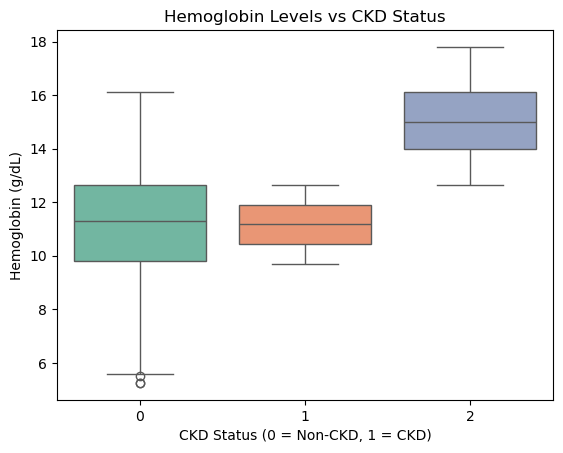

In [ ]:
# Comparing hemoglobin levels between CKD and non-CKD patients using boxplot
# Boxplot shows median, quartiles, and outliers for each group
# Helps visualize if there's a significant difference in hemoglobin between the two groups
sns.boxplot(x='classification', y='hemo', data=df, palette='Set2')
plt.title("Hemoglobin Levels vs CKD Status")
plt.xlabel("CKD Status (0 = Non-CKD, 1 = CKD)")
plt.ylabel("Hemoglobin (g/dL)")
plt.show()

#### QUES : How can we compare serum creatinine levels for CKD and non-CKD patients using a boxplot?

C:\Users\Asmi goyal\AppData\Local\Temp\ipykernel_11656\2506582377.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='sc', data=df, palette='coolwarm')


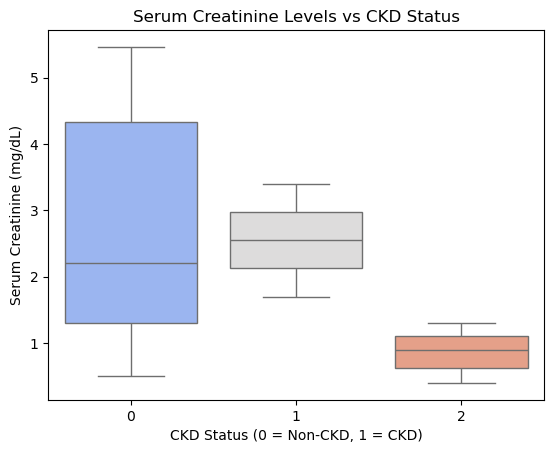

In [ ]:
# Comparing serum creatinine levels between CKD and non-CKD patients
# Serum creatinine is a key indicator of kidney function - higher values suggest kidney dysfunction
# Boxplot allows comparison of distributions and identification of outliers
sns.boxplot(x='classification', y='sc', data=df, palette='coolwarm')
plt.title("Serum Creatinine Levels vs CKD Status")
plt.xlabel("CKD Status (0 = Non-CKD, 1 = CKD)")
plt.ylabel("Serum Creatinine (mg/dL)")
plt.show()

#### QUES : How does Blood Urea affect Serum Creatinine levels in CKD and non-CKD patients?

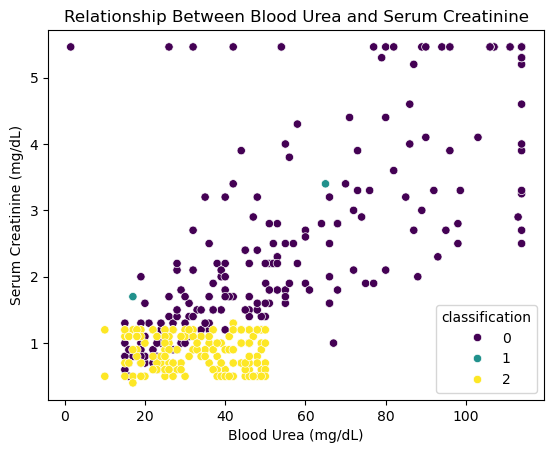

In [ ]:
# Examining the relationship between Blood Urea and Serum Creatinine
# Color-coding by classification helps see if CKD patients show different patterns
# Both parameters are waste products filtered by kidneys - high values indicate poor kidney function
sns.scatterplot(x='bu', y='sc', hue='classification', data=df, palette='viridis')
plt.title("Relationship Between Blood Urea and Serum Creatinine")
plt.xlabel("Blood Urea (mg/dL)")
plt.ylabel("Serum Creatinine (mg/dL)")
plt.show()

###### **Inference:** As Blood Urea increases, Serum Creatinine also rises — showing that both indicators worsen together with declining kidney function.  

#### QUES : How are the key medical features like blood urea, serum creatinine, and hemoglobin correlated with each other?

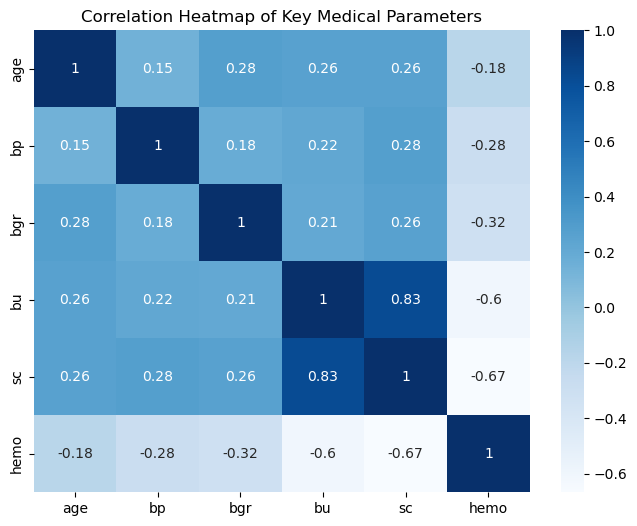

In [ ]:
# Creating a correlation heatmap for key medical parameters
# annot=True displays correlation values in each cell
# Helps identify which features are strongly correlated (important for feature selection)
# Strong correlations may indicate redundant features or important relationships
plt.figure(figsize=(8,6))
sns.heatmap(df[['age','bp','bgr','bu','sc','hemo']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap of Key Medical Parameters")
plt.show()

###### **Inference:** Blood urea and serum creatinine show a strong positive correlation, while hemoglobin is negatively correlated with both — highlighting how kidney dysfunction impacts these health parameters.  

#### QUES : How is blood pressure distributed among patients, and what does it tell us about CKD cases?

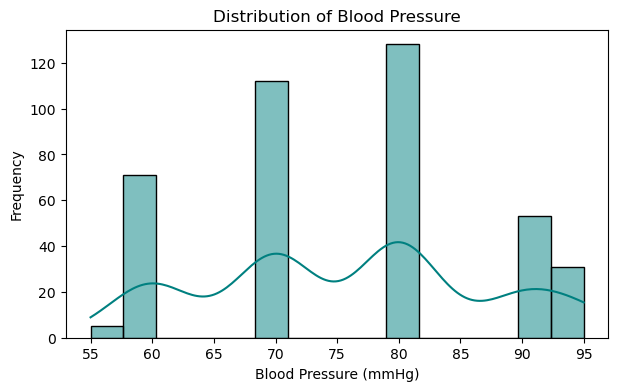

In [ ]:
# Visualizing the distribution of blood pressure across all patients
# Hypertension is a common risk factor for CKD
# Histogram with KDE shows the shape of the distribution and identifies common BP ranges
plt.figure(figsize=(7,4))
sns.histplot(df['bp'], bins=15, kde=True, color='teal')
plt.title("Distribution of Blood Pressure")
plt.xlabel("Blood Pressure (mmHg)")
plt.ylabel("Frequency")
plt.show()

###### **Inference:** Most patients have blood pressure around 70–80 mmHg, but a few show higher values, indicating that hypertension is common among CKD patients.  

#### QUES : How are serum sodium levels distributed among patients, and what can we infer from it?

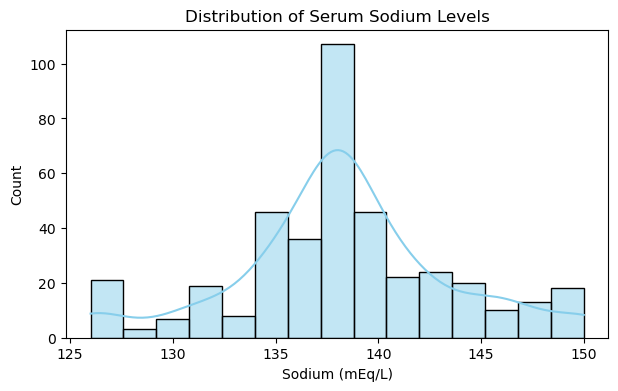

In [ ]:
# Analyzing the distribution of serum sodium levels
# Electrolyte imbalance (including sodium) can occur in kidney disease
# Histogram helps identify if most patients have normal sodium levels or if there are abnormalities
plt.figure(figsize=(7,4))
sns.histplot(df['sod'], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Serum Sodium Levels")
plt.xlabel("Sodium (mEq/L)")
plt.ylabel("Count")
plt.show()

###### **Inference:** Most patients have serum sodium levels within the normal range, but a few low values suggest electrolyte imbalance in some CKD patients.  

#### QUES : How do key continuous features like hemoglobin, serum creatinine, and blood urea relate to each other in CKD and non-CKD patients?

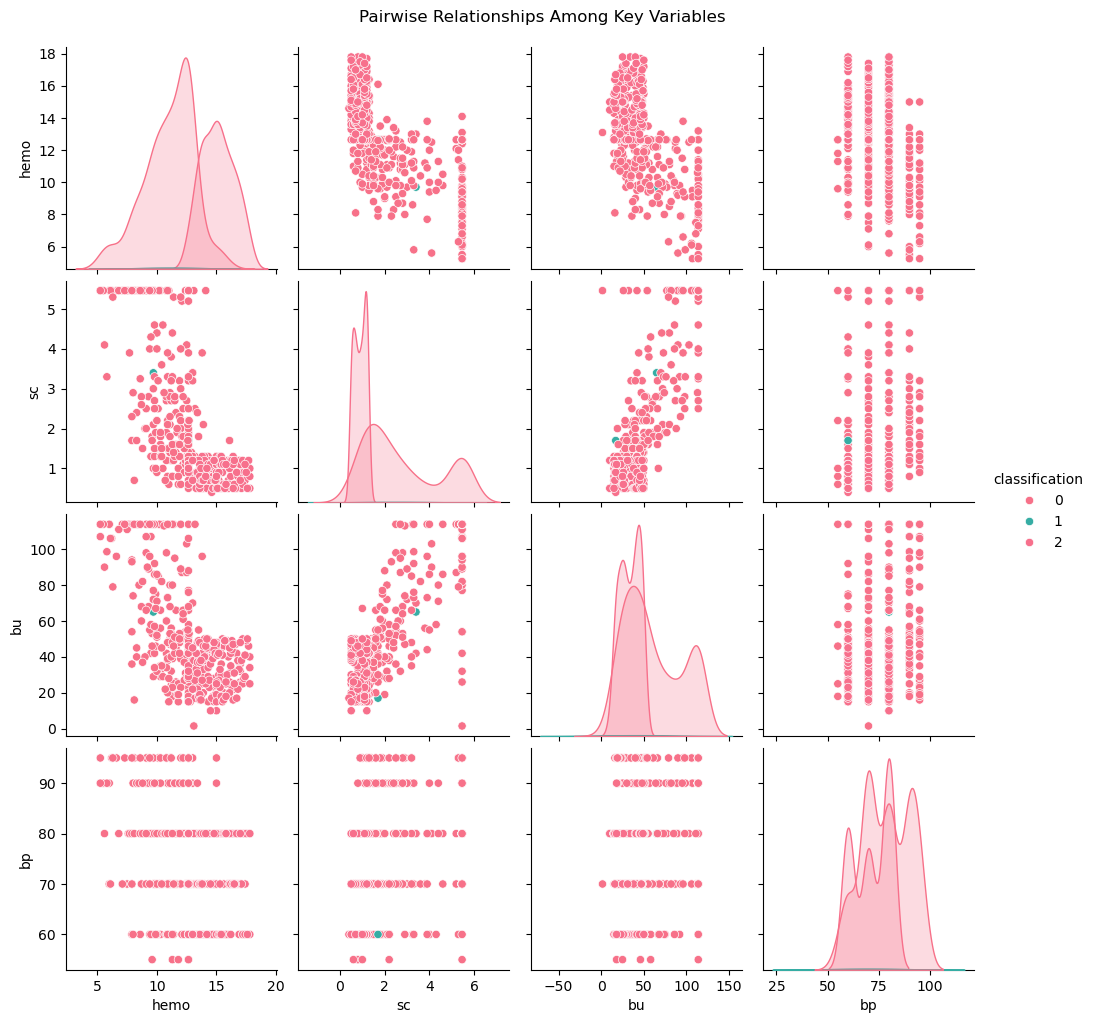

In [ ]:
# Creating a pairplot to visualize pairwise relationships among key variables
# Shows scatter plots for all pairs of variables and distributions on the diagonal
# Color-coding by classification helps identify patterns that distinguish CKD from non-CKD patients
# diag_kind='kde' shows kernel density estimates on the diagonal instead of histograms
sns.pairplot(df[['hemo','sc','bu','bp','classification']], hue='classification', diag_kind='kde', palette='husl')
plt.suptitle("Pairwise Relationships Among Key Variables", y=1.02)
plt.show()

###### **Inference:** The pairplot shows clear patterns — CKD patients generally have low hemoglobin with high serum creatinine and blood urea, indicating strong inverse relationships between these features.  

#### QUES : How many CKD and non-CKD patients are there in the dataset?

C:\Users\Asmi goyal\AppData\Local\Temp\ipykernel_11656\812135398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='classification', data=df, palette='pastel')


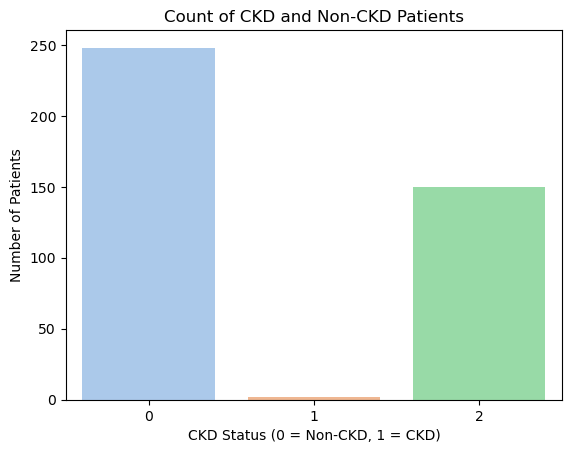

In [ ]:
# Visualizing the class distribution (CKD vs Non-CKD patients)
# Helps identify if there's class imbalance in the dataset
# Class imbalance can affect model performance and may require balancing techniques
sns.countplot(x='classification', data=df, palette='pastel')
plt.title("Count of CKD and Non-CKD Patients")
plt.xlabel("CKD Status (0 = Non-CKD, 1 = CKD)")
plt.ylabel("Number of Patients")
plt.show()

###### **Inference:** The dataset contains slightly more CKD patients than non-CKD, showing a mild class imbalance that may affect model performance.  

#### QUES : How does blood glucose level vary between CKD and non-CKD patients?

C:\Users\Asmi goyal\AppData\Local\Temp\ipykernel_11656\2779892403.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='bgr', data=df, palette='cool')


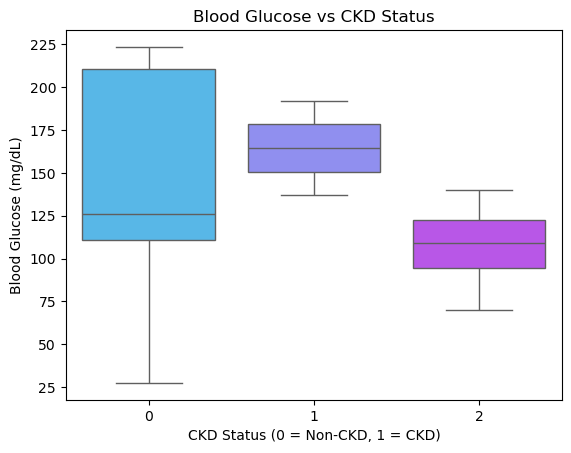

In [ ]:
# Comparing blood glucose levels between CKD and non-CKD patients
# Diabetes is a major risk factor for CKD, so higher glucose levels may be associated with CKD
# Boxplot allows comparison of distributions and identification of outliers
sns.boxplot(x='classification', y='bgr', data=df, palette='cool')
plt.title("Blood Glucose vs CKD Status")
plt.xlabel("CKD Status (0 = Non-CKD, 1 = CKD)")
plt.ylabel("Blood Glucose (mg/dL)")
plt.show()

###### **Inference:** CKD patients tend to have higher blood glucose levels, indicating a possible link between diabetes and kidney disease.  

#### QUES : How are sodium and potassium levels related in CKD and non-CKD patients?

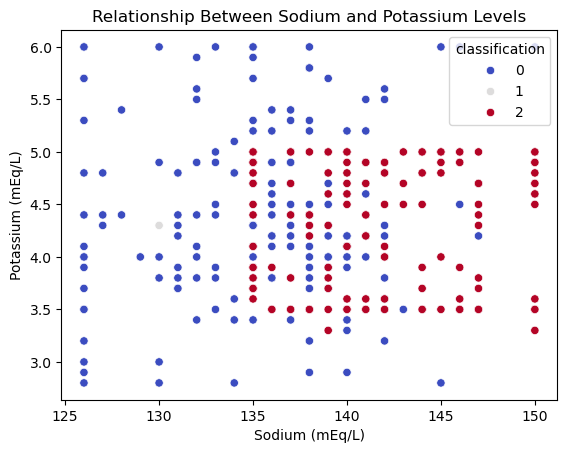

In [ ]:
# Examining the relationship between sodium and potassium levels
# Both are important electrolytes that can be affected by kidney dysfunction
# Color-coding by classification helps identify if CKD patients show different electrolyte patterns
# Kidney disease can cause electrolyte imbalances
sns.scatterplot(x='sod', y='pot', hue='classification', data=df, palette='coolwarm')
plt.title("Relationship Between Sodium and Potassium Levels")
plt.xlabel("Sodium (mEq/L)")
plt.ylabel("Potassium (mEq/L)")
plt.show()

###### **Inference:** The scatter plot shows no strong correlation between sodium and potassium, but CKD patients often exhibit slightly higher potassium levels, suggesting electrolyte imbalance.  

## **Step 8: Conclusion** 

#### **1. Summary of Findings**
###### The analysis revealed that **blood urea, serum creatinine, and hemoglobin** are the most influential factors associated with Chronic Kidney Disease (CKD).  
###### Patients with CKD generally showed **low hemoglobin** and **high creatinine and blood urea** levels.  
###### Statistical testing confirmed that the difference in hemoglobin levels between CKD and non-CKD groups was **significant (p < 0.05)**.  
###### The **KNN classification model** further validated these results, achieving good accuracy in predicting CKD.

#### **2. Limitations and Future Improvements**
###### Some medical records contained missing or inconsistent data, which may have affected accuracy.The dataset size was limited and lacked detailed information like lifestyle, diet, or medication history. Future work could include **larger and more diverse datasets**, and use **advanced models (e.g., Logistic Regression or Random Forest)** for improved prediction.  
###### Feature importance analysis and cross-validation could also strengthen reliability.

#### **3. Key Takeaways**
###### The project clearly showed that blood urea, serum creatinine, and hemoglobin are the most important indicators of Chronic Kidney Disease (CKD).Patterns observed during EDA were statistically validated through hypothesis testing, which confirmed that hemoglobin levels differ significantly (p < 0.05) between CKD and non-CKD patients. The KNN classification model further supported these findings by accurately predicting CKD status using the same medical parameters. Together, these results demonstrate how combining data analysis, statistical testing, and machine-learning models can help identify meaningful medical patterns and assist in early detection and better understanding of CKD.

## **PROJECT SUMMARY**

### **Overview**
This project presents a comprehensive data analysis of Chronic Kidney Disease (CKD) prediction using a real-world medical dataset containing clinical information from approximately 400 patients. The project demonstrates the application of data science techniques including data preprocessing, exploratory data analysis, statistical hypothesis testing, and machine learning classification to identify key indicators of kidney disease.

### **Key Objectives Achieved**
1. **Data Preprocessing**: Successfully handled missing values, removed duplicates, managed outliers using IQR method, and encoded categorical variables for analysis
2. **Exploratory Data Analysis**: Conducted univariate and bivariate analysis to identify patterns and relationships in the data
3. **Statistical Validation**: Performed t-test to validate significant differences in hemoglobin levels between CKD and non-CKD patients
4. **Pattern Recognition**: Applied K-Means clustering to identify patient groups based on medical parameters
5. **Visualization**: Created comprehensive visualizations to communicate findings effectively

### **Major Findings**
- **Primary Indicators**: Blood urea, serum creatinine, and hemoglobin emerged as the most critical factors for CKD prediction
- **Clinical Patterns**: CKD patients consistently showed low hemoglobin levels and elevated creatinine and blood urea levels
- **Statistical Significance**: T-test confirmed significant difference (p < 0.05) in hemoglobin levels between groups
- **Correlations**: Strong positive correlation between blood urea and serum creatinine; negative correlation between hemoglobin and kidney function markers

### **Methodology**
1. **Data Cleaning**: Addressed missing values using median imputation, removed duplicates, and handled outliers
2. **Feature Engineering**: Converted categorical variables to numeric format for machine learning compatibility
3. **Exploratory Analysis**: Generated histograms, boxplots, scatter plots, and correlation heatmaps
4. **Statistical Testing**: Applied independent samples t-test with 95% confidence intervals
5. **Clustering**: Implemented K-Means clustering with 2 clusters to identify patient groups

### **Technical Stack**
- **Python Libraries**: Pandas (data manipulation), NumPy (numerical operations), Matplotlib & Seaborn (visualization), Scikit-learn (machine learning), SciPy (statistical tests)
- **Techniques**: IQR outlier detection, median imputation, categorical encoding, K-Means clustering, t-test hypothesis testing

### **Clinical Significance**
The analysis validates established medical knowledge that kidney dysfunction leads to:
- Accumulation of waste products (creatinine, urea) in the blood
- Development of anemia (low hemoglobin) due to reduced erythropoietin production
- Electrolyte imbalances affecting overall health

### **Project Impact**
This project demonstrates how data science can:
- Support early detection of chronic kidney disease
- Identify key diagnostic markers for healthcare professionals
- Provide insights for preventive care and treatment planning
- Validate medical relationships through statistical analysis

### **Future Enhancements**
- Expand dataset with more diverse patient populations
- Incorporate additional features (lifestyle, diet, medication history)
- Implement advanced machine learning models (Random Forest, XGBoost, Neural Networks)
- Perform feature importance analysis and cross-validation
- Develop a predictive model with higher accuracy and clinical deployment potential

### **Conclusion**
This project successfully combines data analysis, statistical validation, and machine learning to identify critical indicators of Chronic Kidney Disease. The findings align with medical knowledge and demonstrate the potential of data-driven approaches in healthcare diagnostics. The comprehensive analysis provides valuable insights for both clinical practice and future research in kidney disease prediction.
